In [1]:
!nvidia-smi

Sun Jun  7 16:55:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             53W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
%%capture
import os
if not os.path.exists('/content/drive/MyDrive/AAAI_TALAS/AAAI-TALAS-main'):
    !unzip /content/drive/MyDrive/AAAI_TALAS/AAAI-TALAS-main.zip

In [4]:
%cd /content/AAAI-TALAS-main

/content/AAAI-TALAS-main


In [5]:
# Remove stale cached teacher embeddings before training
!rm -rf cache
!mkdir -p cache
!echo "Removed cache/"

Removed cache/


In [6]:
!pip install -r requirements.txt

In [7]:
!sed -i 's|\.\./main.py|main.py|g' scripts/train_talas.sh
!sed -i 's|TRAIN_DATA=.*|TRAIN_DATA="data/merged_9_data_3k_each_ver2.csv"|g' scripts/train_talas.sh
!sed -i 's|TEACHER_MODEL=.*|TEACHER_MODEL="Qwen/Qwen3-Embedding-4B"|g' scripts/train_talas.sh
!sed -i 's|STUDENT_MODEL=.*|STUDENT_MODEL="google-bert/bert-base-uncased"|g' scripts/train_talas.sh
!cat scripts/train_talas.sh | grep -E "TRAIN_DATA|TEACHER_MODEL|STUDENT_MODEL"

!sed -i -E 's/BATCH_SIZE=[0-9]+/BATCH_SIZE=256/g' scripts/train_talas.sh
!sed -i -E 's/(--batch_size\s+)[0-9]+/\1256/g' scripts/train_talas.sh
!sed -i -E 's/(--per_device_train_batch_size\s+)[0-9]+/\1256/g' scripts/train_talas.sh

# Kiểm tra lại các dòng có chứa từ khoá batch trong script
!cat scripts/train_talas.sh | grep -i "batch"
!test -f data/test_debug.csv || (echo 'Missing data/test_debug.csv. Re-run the unzip cell or check the archive.' && false)
!mkdir -p analysis/talas_diagnostics
!bash -c 'set -o pipefail; bash scripts/train_talas.sh 2>&1 | tee analysis/talas_diagnostics/train_talas.log'

TRAIN_DATA="data/merged_9_data_3k_each_ver2.csv"
STUDENT_MODEL="google-bert/bert-base-uncased"
TEACHER_MODEL="Qwen/Qwen3-Embedding-4B"
    --train_data $TRAIN_DATA \
    --student_model $STUDENT_MODEL \
    --teacher_model $TEACHER_MODEL \
BATCH_SIZE=256
    --batch_size $BATCH_SIZE \
Training with TALAS method

Configuration for TALAS method:
  train_data_path           : data/merged_9_data_3k_each_ver2.csv
  student_model_name        : google-bert/bert-base-uncased
  teacher_model_name        : Qwen/Qwen3-Embedding-4B
  batch_size                : 256
  epochs                    : 5
  learning_rate             : 2e-05
  max_length                : 256
  save_dir                  : checkpoints/talas

Done setup_seed with seed=42
[WARN] Only 1 GPU available -> both on cuda:0
Done setup_devices
Loading tokenizers...
Loading student model: google-bert/bert-base-uncased
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6179.97it/s]
[transformers] BertModel LOAD REPORT from: google-b

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Diagnostics checkpoint: checkpoints/talas/best_model.pt
Student: google-bert/bert-base-uncased
Teacher for STS calibration: Qwen/Qwen3-Embedding-4B
Training data sample source: data/merged_9_data_3k_each_ver2.csv


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Student hidden-state probe:   0%|          | 0/8 [00:00<?, ?it/s]

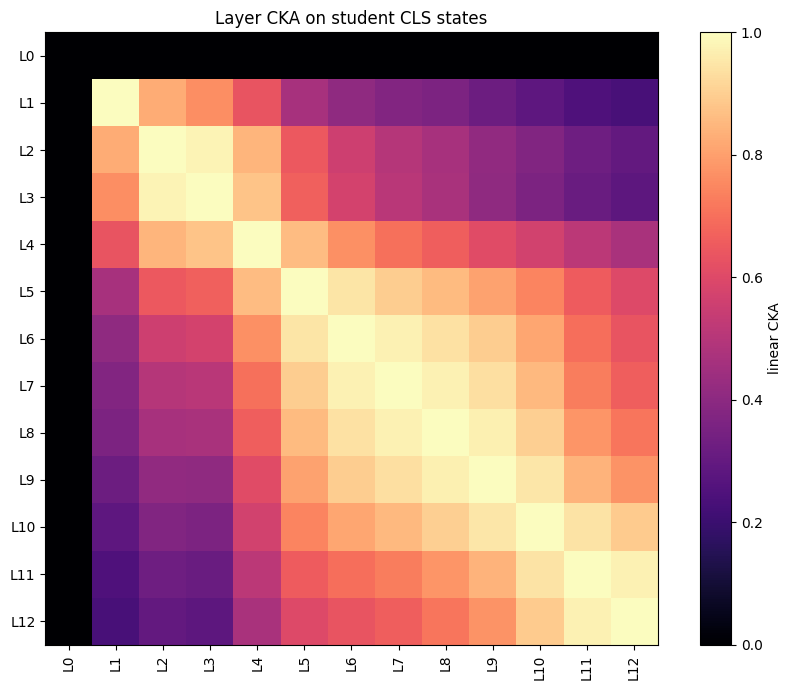

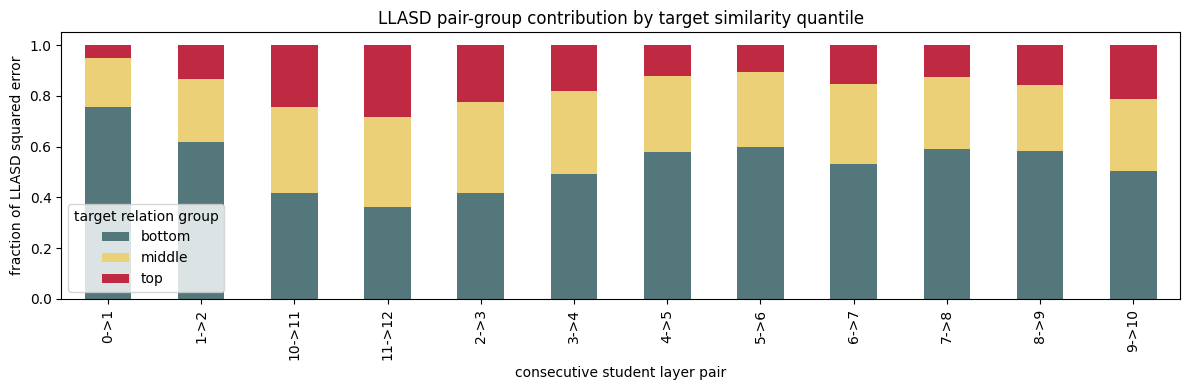

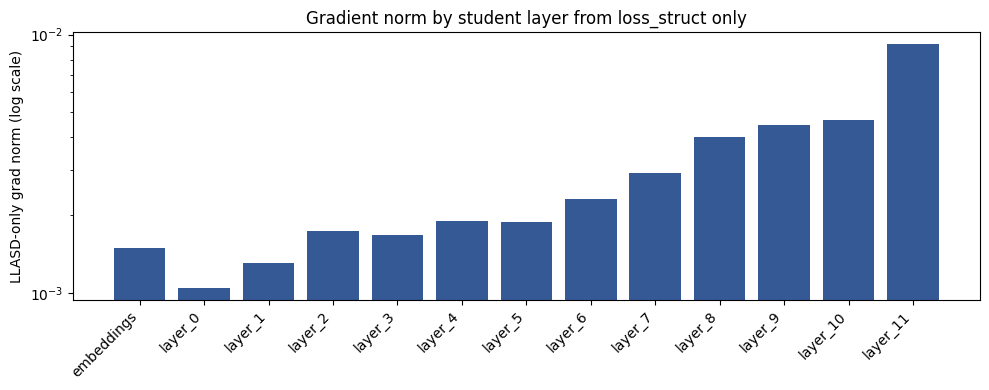

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Embedding probe (cls):   0%|          | 0/8 [00:00<?, ?it/s]

Embedding probe (cls):   0%|          | 0/8 [00:00<?, ?it/s]

Embedding probe (last_token):   0%|          | 0/8 [00:00<?, ?it/s]

...

Embedding probe (last_token):   0%|          | 0/8 [00:00<?, ?it/s]

Embedding probe (cls):   0%|          | 0/8 [00:00<?, ?it/s]

Embedding probe (cls):   0%|          | 0/8 [00:00<?, ?it/s]

Embedding probe (last_token):   0%|          | 0/8 [00:00<?, ?it/s]

Embedding probe (last_token):   0%|          | 0/8 [00:00<?, ?it/s]

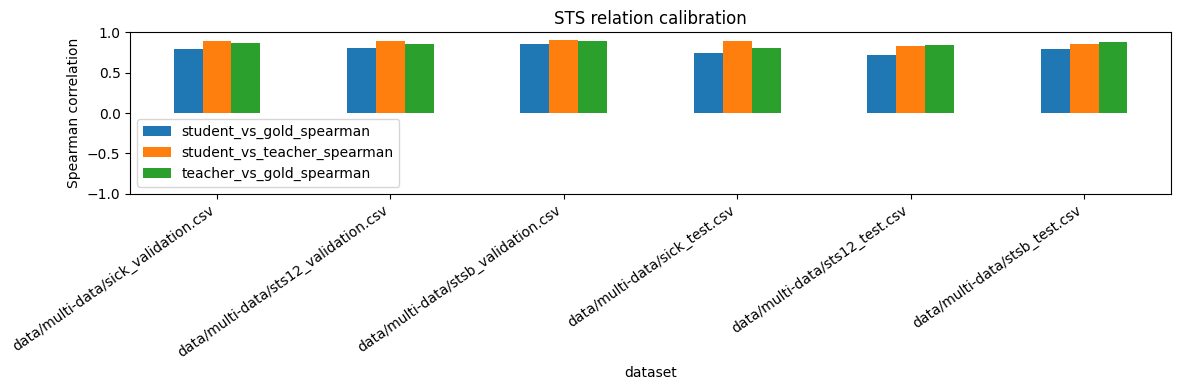

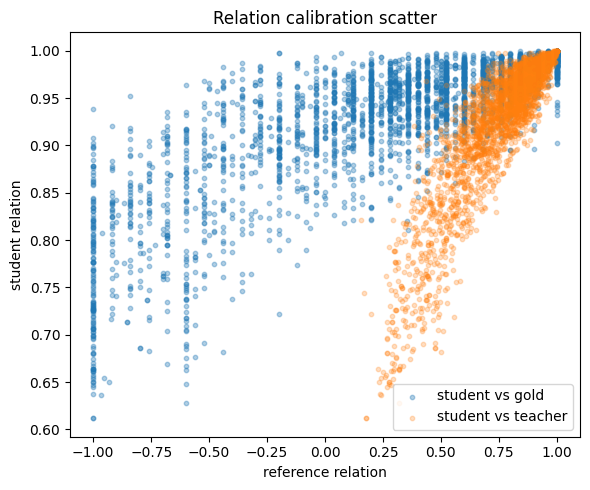


Saved TALAS diagnostics to: /content/AAAI-TALAS-main/analysis/talas_diagnostics
- analysis/talas_diagnostics/train_talas.log
- analysis/talas_diagnostics/layer_cka.csv
- analysis/talas_diagnostics/layer_cka.png
- analysis/talas_diagnostics/pair_group_contribution.csv
- analysis/talas_diagnostics/pair_group_contribution.png
- analysis/talas_diagnostics/grad_norm_by_layer.csv
- analysis/talas_diagnostics/grad_norm_by_layer.png
- analysis/talas_diagnostics/relation_calibration_sts.csv
- analysis/talas_diagnostics/relation_calibration_sts_points.csv
- analysis/talas_diagnostics/relation_calibration_sts.png

Layer CKA (last 5x5):


,L8,L9,L10,L11,L12
L8,1.000012,0.969931,0.900106,0.779540,0.711228
L9,0.969931,1.000012,0.951940,0.842155,0.776144
L10,0.900106,0.951940,1.000011,0.944047,0.891477
L11,0.779540,0.842155,0.944047,1.000013,0.974237
L12,0.711228,0.776144,0.891477,0.974237,1.000010



Pair-group contribution preview:


,layer_from,layer_to,layer_pair,group,count,mean_target_relation,mean_sq_error,sse,frac_sse
0,0,1,0->1,bottom,43606,0.975812,0.000615,26.838945,0.755564
1,0,1,0->1,middle,43605,0.987606,0.000159,6.921786,0.194861
2,0,1,0->1,top,43605,0.993849,0.000040,1.761015,0.049576
3,1,2,1->2,bottom,43606,0.964122,0.000258,11.248554,0.617750
4,1,2,1->2,middle,43605,0.977517,0.000104,4.525574,0.248536
5,1,2,1->2,top,43605,0.985816,0.000056,2.434781,0.133714
6,2,3,2->3,bottom,43607,0.967240,0.000017,0.747219,0.415242
7,2,3,2->3,middle,43604,0.980548,0.000015,0.647880,0.360037
8,2,3,2->3,top,43605,0.988137,0.000009,0.404381,0.224721
9,3,4,3->4,bottom,43607,0.954239,0.000273,11.895306,0.490065



Gradient norm by layer:


,layer,layer_order,n_params_with_grad,grad_norm,param_norm,grad_param_ratio,loss_struct_probe
0,embeddings,-1,23837184,0.001488,248.502209,0.000006,0.000747
1,layer_0,0,7087872,0.001047,104.080935,0.000010,0.000747
2,layer_1,1,7087872,0.001306,106.596270,0.000012,0.000747
3,layer_2,2,7087872,0.001732,109.358046,0.000016,0.000747
4,layer_3,3,7087872,0.001680,109.173444,0.000015,0.000747
5,layer_4,4,7087872,0.001901,110.734957,0.000017,0.000747
6,layer_5,5,7087872,0.001878,110.799587,0.000017,0.000747
7,layer_6,6,7087872,0.002302,109.956711,0.000021,0.000747
8,layer_7,7,7087872,0.002907,107.247373,0.000027,0.000747
9,layer_8,8,7087872,0.004026,108.343664,0.000037,0.000747



STS relation calibration:


,dataset,n,student_vs_gold_pearson,student_vs_gold_spearman,student_vs_teacher_pearson,student_vs_teacher_spearman,teacher_vs_gold_pearson,teacher_vs_gold_spearman,student_teacher_mae
0,data/multi-data/sick_validation.csv,500,0.833166,0.798426,0.892916,0.889563,0.891460,0.862925,0.148553
1,data/multi-data/sts12_validation.csv,512,0.857128,0.811930,0.919970,0.890074,0.913181,0.852466,0.156770
2,data/multi-data/stsb_validation.csv,512,0.824341,0.854877,0.883689,0.901813,0.886053,0.886715,0.216879
3,data/multi-data/sick_test.csv,512,0.833399,0.746153,0.896772,0.890024,0.866498,0.806336,0.151866
4,data/multi-data/sts12_test.csv,512,0.794750,0.717704,0.888298,0.835952,0.890202,0.845986,0.129325
5,data/multi-data/stsb_test.csv,512,0.768106,0.796558,0.862324,0.857847,0.867866,0.878657,0.183166


In [8]:
# TALAS / LLASD diagnostics: log + visualize post-training signals.
# This notebook treats LLASD as TeacherAnchorKD.loss_struct: MSE between
# pairwise in-batch relation matrices of consecutive student CLS layers.

import gc
import json
import math
import re
from contextlib import nullcontext
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer

from src.evaluation.evaluation_automodel import eval_sts_tasks, test_sts_tasks
from src.pooling import last_token_pool, mean_pooling

DIAG_DIR = Path("analysis/talas_diagnostics")
DIAG_DIR.mkdir(parents=True, exist_ok=True)

# Keep these modest for fast Colab probes; increase after the pipeline works.
TRAIN_SAMPLE_TEXTS = 512
STS_SAMPLE_PER_FILE = 512
DIAG_BATCH_SIZE = 64
GRAD_BATCH_SIZE = 32
RUN_TEACHER_STS_CALIBRATION = True
RANDOM_SEED = 42

checkpoint_dir = Path("checkpoints/talas")
best_checkpoint = checkpoint_dir / "best_model.pt"
if best_checkpoint.exists():
    checkpoint_path = best_checkpoint
else:
    checkpoints = sorted(
        checkpoint_dir.glob("checkpoint_epoch_*.pt"),
        key=lambda p: int(re.search(r"checkpoint_epoch_(\d+)", p.stem).group(1)),
    )
    assert checkpoints, f"No checkpoint found in {checkpoint_dir}"
    checkpoint_path = checkpoints[-1]

try:
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
except TypeError:
    checkpoint = torch.load(checkpoint_path, map_location="cpu")

cfg = checkpoint.get("config", {})
student_model_name = cfg.get("student_model_name", "google-bert/bert-base-uncased")
teacher_model_name = cfg.get("teacher_model_name", "Qwen/Qwen3-Embedding-0.6B")
train_data_path = Path(cfg.get("train_data_path", "data/merged_3_data_5k_each.csv"))
task_type = cfg.get("task_type", "pair_cls")
max_length = int(cfg.get("max_length", 256))
start_rkd = int(cfg.get("start_rkd", 0))
teacher_dtype_name = cfg.get("teacher_dtype", "bfloat16")
teacher_pooling = cfg.get("pooling_method", "last_token")

print(f"Diagnostics checkpoint: {checkpoint_path}")
print(f"Student: {student_model_name}")
print(f"Teacher for STS calibration: {teacher_model_name}")
print(f"Training data sample source: {train_data_path}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
student_tokenizer = AutoTokenizer.from_pretrained(student_model_name)
student_model = AutoModel.from_pretrained(student_model_name)
student_model.load_state_dict(checkpoint["model_state_dict"])
student_model.to(device)
student_model.eval()


def autocast_for(device):
    if device.type == "cuda":
        return torch.amp.autocast("cuda", dtype=torch.float16)
    return nullcontext()


def safe_corr(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return {"pearson": np.nan, "spearman": np.nan, "n": int(len(x))}
    return {
        "pearson": float(pearsonr(x, y).statistic),
        "spearman": float(spearmanr(x, y).statistic),
        "n": int(len(x)),
    }


def get_first_side_texts(df, task_type):
    if task_type == "single_cls":
        return df["text"].astype(str).tolist()
    if "premise" in df.columns:
        return df["premise"].astype(str).tolist()
    if "sentence1" in df.columns:
        return df["sentence1"].astype(str).tolist()
    if "text" in df.columns:
        return df["text"].astype(str).tolist()
    return df.iloc[:, 0].astype(str).tolist()


def batched(iterable, batch_size):
    for start in range(0, len(iterable), batch_size):
        yield iterable[start:start + batch_size]


def encode_texts(tokenizer, texts, max_length, device):
    encoded = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt",
    )
    return {k: v.to(device) for k, v in encoded.items() if torch.is_tensor(v)}


def collect_student_cls_layers(model, tokenizer, texts, batch_size, max_length, device):
    layer_chunks = None
    model.eval()
    with torch.no_grad():
        for batch_texts in tqdm(list(batched(texts, batch_size)), desc="Student hidden-state probe"):
            batch = encode_texts(tokenizer, batch_texts, max_length, device)
            with autocast_for(device):
                out = model(**batch, output_hidden_states=True, return_dict=True)
            cls_layers = [h[:, 0, :].detach().float().cpu() for h in out.hidden_states]
            if layer_chunks is None:
                layer_chunks = [[] for _ in cls_layers]
            for idx, cls in enumerate(cls_layers):
                layer_chunks[idx].append(cls)
    return [torch.cat(chunks, dim=0) for chunks in layer_chunks]


def linear_cka(x, y, eps=1e-12):
    x = x.float() - x.float().mean(dim=0, keepdim=True)
    y = y.float() - y.float().mean(dim=0, keepdim=True)
    xty = x.T @ y
    xtx = x.T @ x
    yty = y.T @ y
    numerator = torch.sum(xty * xty)
    denominator = torch.linalg.matrix_norm(xtx) * torch.linalg.matrix_norm(yty)
    return float((numerator / denominator.clamp_min(eps)).cpu())


def relation_matrix(x, eps=1e-12):
    x = F.normalize(x.float(), dim=-1, eps=eps)
    return x @ x.T


def upper_triangle_values(matrix):
    n = matrix.shape[0]
    idx = torch.triu_indices(n, n, offset=1, device=matrix.device)
    return matrix[idx[0], idx[1]]


def pair_group_contribution(cls_layers, start_rkd=0):
    rows = []
    for layer_idx in range(start_rkd, len(cls_layers) - 1):
        source_relation = relation_matrix(cls_layers[layer_idx])
        target_relation = relation_matrix(cls_layers[layer_idx + 1])
        source_vals = upper_triangle_values(source_relation)
        target_vals = upper_triangle_values(target_relation)
        sq_error = (source_vals - target_vals).pow(2)
        if sq_error.numel() == 0:
            continue
        q1, q2 = torch.quantile(target_vals.float(), torch.tensor([1 / 3, 2 / 3], device=target_vals.device))
        groups = {
            "bottom": target_vals <= q1,
            "middle": (target_vals > q1) & (target_vals <= q2),
            "top": target_vals > q2,
        }
        total_sse = float(sq_error.sum().item())
        for group_name, mask in groups.items():
            count = int(mask.sum().item())
            group_sse = float(sq_error[mask].sum().item()) if count else 0.0
            rows.append({
                "layer_from": layer_idx,
                "layer_to": layer_idx + 1,
                "layer_pair": f"{layer_idx}->{layer_idx + 1}",
                "group": group_name,
                "count": count,
                "mean_target_relation": float(target_vals[mask].mean().item()) if count else np.nan,
                "mean_sq_error": float(sq_error[mask].mean().item()) if count else np.nan,
                "sse": group_sse,
                "frac_sse": group_sse / total_sse if total_sse else np.nan,
            })
    return pd.DataFrame(rows)


def llasd_grad_norm_by_layer(model, tokenizer, texts, batch_size, max_length, device, start_rkd=0):
    model.zero_grad(set_to_none=True)
    model.eval()
    batch = encode_texts(tokenizer, texts[:batch_size], max_length, device)
    out = model(**batch, output_hidden_states=True, return_dict=True)
    cls_layers = [h[:, 0, :] for h in out.hidden_states]
    loss_terms = []
    for layer_idx in range(start_rkd, len(cls_layers) - 1):
        source_relation = relation_matrix(cls_layers[layer_idx])
        target_relation = relation_matrix(cls_layers[layer_idx + 1])
        loss_terms.append(F.mse_loss(source_relation, target_relation))
    loss_struct = torch.stack(loss_terms).mean()
    loss_struct.backward()

    rows_by_layer = {}
    for name, param in model.named_parameters():
        if param.grad is None:
            continue
        if name.startswith("embeddings."):
            layer_key = "embeddings"
            layer_order = -1
        else:
            match = re.search(r"encoder\.layer\.(\d+)\.", name)
            if match:
                layer_order = int(match.group(1))
                layer_key = f"layer_{layer_order}"
            else:
                layer_key = "other"
                layer_order = 10_000
        row = rows_by_layer.setdefault(layer_key, {
            "layer": layer_key,
            "layer_order": layer_order,
            "grad_sq_sum": 0.0,
            "param_sq_sum": 0.0,
            "n_params_with_grad": 0,
        })
        row["grad_sq_sum"] += float(param.grad.detach().float().pow(2).sum().cpu())
        row["param_sq_sum"] += float(param.detach().float().pow(2).sum().cpu())
        row["n_params_with_grad"] += int(param.numel())

    rows = []
    for row in rows_by_layer.values():
        grad_norm = math.sqrt(row.pop("grad_sq_sum"))
        param_norm = math.sqrt(row.pop("param_sq_sum"))
        row["grad_norm"] = grad_norm
        row["param_norm"] = param_norm
        row["grad_param_ratio"] = grad_norm / max(param_norm, 1e-12)
        row["loss_struct_probe"] = float(loss_struct.detach().cpu())
        rows.append(row)
    model.zero_grad(set_to_none=True)
    return pd.DataFrame(rows).sort_values("layer_order").reset_index(drop=True)


def collect_embeddings(model, tokenizer, texts, batch_size, max_length, device, pooling="cls"):
    chunks = []
    model.eval()
    with torch.no_grad():
        for batch_texts in tqdm(list(batched(texts, batch_size)), desc=f"Embedding probe ({pooling})"):
            batch = encode_texts(tokenizer, batch_texts, max_length, device)
            with autocast_for(device):
                out = model(**batch, return_dict=True)
            if pooling == "last_token":
                emb = last_token_pool(out.last_hidden_state, batch["attention_mask"])
            elif pooling == "mean":
                emb = mean_pooling(out.last_hidden_state, batch["attention_mask"])
            else:
                emb = out.last_hidden_state[:, 0, :]
            chunks.append(F.normalize(emb.float(), dim=-1).detach().cpu())
    return torch.cat(chunks, dim=0)


def load_teacher_for_sts(model_name, dtype_name):
    teacher_device = torch.device("cuda:1" if torch.cuda.device_count() > 1 else device)
    kwargs = {"trust_remote_code": True}
    if teacher_device.type == "cuda":
        if dtype_name == "bfloat16":
            kwargs["torch_dtype"] = torch.bfloat16
        elif dtype_name == "float16":
            kwargs["torch_dtype"] = torch.float16
    teacher_tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    teacher_model = AutoModel.from_pretrained(model_name, **kwargs)
    teacher_model.to(teacher_device)
    teacher_model.eval()
    for p in teacher_model.parameters():
        p.requires_grad_(False)
    return teacher_model, teacher_tokenizer, teacher_device


# 1) Layer CKA: are student layers becoming too similar?
train_df = pd.read_csv(train_data_path)
train_texts = get_first_side_texts(train_df, task_type)
rng = np.random.default_rng(RANDOM_SEED)
if len(train_texts) > TRAIN_SAMPLE_TEXTS:
    sample_idx = rng.choice(len(train_texts), size=TRAIN_SAMPLE_TEXTS, replace=False)
    train_texts = [train_texts[i] for i in sample_idx]

cls_layers = collect_student_cls_layers(
    student_model, student_tokenizer, train_texts, DIAG_BATCH_SIZE, max_length, device
)
num_layers = len(cls_layers)
cka = np.zeros((num_layers, num_layers), dtype=np.float32)
for i in range(num_layers):
    for j in range(i, num_layers):
        value = linear_cka(cls_layers[i], cls_layers[j])
        cka[i, j] = cka[j, i] = value

cka_df = pd.DataFrame(cka, index=[f"L{i}" for i in range(num_layers)], columns=[f"L{i}" for i in range(num_layers)])
cka_df.to_csv(DIAG_DIR / "layer_cka.csv")

plt.figure(figsize=(9, 7))
plt.imshow(cka_df.values, vmin=0, vmax=1, cmap="magma")
plt.colorbar(label="linear CKA")
plt.xticks(range(num_layers), cka_df.columns, rotation=90)
plt.yticks(range(num_layers), cka_df.index)
plt.title("Layer CKA on student CLS states")
plt.tight_layout()
plt.savefig(DIAG_DIR / "layer_cka.png", dpi=180)
plt.show()

# 2) Pair-group contribution: top/middle/bottom relation pairs in LLASD.
pair_group_df = pair_group_contribution(cls_layers, start_rkd=start_rkd)
pair_group_df.to_csv(DIAG_DIR / "pair_group_contribution.csv", index=False)

if not pair_group_df.empty:
    group_order = ["bottom", "middle", "top"]
    pivot = pair_group_df.pivot_table(index="layer_pair", columns="group", values="frac_sse", aggfunc="sum").fillna(0)
    pivot = pivot[[g for g in group_order if g in pivot.columns]]
    ax = pivot.plot(kind="bar", stacked=True, figsize=(12, 4), color=["#53777A", "#ECD078", "#C02942"][:len(pivot.columns)])
    ax.set_ylabel("fraction of LLASD squared error")
    ax.set_xlabel("consecutive student layer pair")
    ax.set_title("LLASD pair-group contribution by target similarity quantile")
    ax.legend(title="target relation group")
    plt.tight_layout()
    plt.savefig(DIAG_DIR / "pair_group_contribution.png", dpi=180)
    plt.show()

# 3) Gradient norm by layer: does LLASD press shallow layers strongly?
grad_df = llasd_grad_norm_by_layer(
    student_model, student_tokenizer, train_texts, GRAD_BATCH_SIZE, max_length, device, start_rkd=start_rkd
)
grad_df.to_csv(DIAG_DIR / "grad_norm_by_layer.csv", index=False)

plot_grad_df = grad_df[grad_df["layer"] != "other"].copy()
if not plot_grad_df.empty:
    plt.figure(figsize=(10, 4))
    plt.bar(plot_grad_df["layer"], plot_grad_df["grad_norm"], color="#345995")
    plt.yscale("log")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("LLASD-only grad norm (log scale)")
    plt.title("Gradient norm by student layer from loss_struct only")
    plt.tight_layout()
    plt.savefig(DIAG_DIR / "grad_norm_by_layer.png", dpi=180)
    plt.show()

# 4) Relation calibration on STS: student vs teacher and gold/final relation.
teacher_model = teacher_tokenizer = teacher_device = None
if RUN_TEACHER_STS_CALIBRATION:
    try:
        teacher_model, teacher_tokenizer, teacher_device = load_teacher_for_sts(teacher_model_name, teacher_dtype_name)
    except Exception as exc:
        print(f"Teacher STS calibration disabled because teacher load failed: {exc}")
        RUN_TEACHER_STS_CALIBRATION = False

calibration_rows = []
scatter_frames = []
sts_paths = list(eval_sts_tasks) + list(test_sts_tasks)
for sts_path in sts_paths:
    path = Path(sts_path)
    if not path.exists():
        print(f"Skipping missing STS file: {sts_path}")
        continue
    df = pd.read_csv(path).dropna(subset=["sentence1", "sentence2", "score"])
    if STS_SAMPLE_PER_FILE and len(df) > STS_SAMPLE_PER_FILE:
        df = df.sample(n=STS_SAMPLE_PER_FILE, random_state=RANDOM_SEED)

    s1 = df["sentence1"].astype(str).tolist()
    s2 = df["sentence2"].astype(str).tolist()
    gold_relation = (df["score"].astype(float).to_numpy() / 2.5) - 1.0

    emb1 = collect_embeddings(student_model, student_tokenizer, s1, DIAG_BATCH_SIZE, max_length, device, pooling="cls")
    emb2 = collect_embeddings(student_model, student_tokenizer, s2, DIAG_BATCH_SIZE, max_length, device, pooling="cls")
    student_relation = F.cosine_similarity(emb1, emb2).numpy()

    row = {"dataset": sts_path, "n": len(df)}
    sg = safe_corr(student_relation, gold_relation)
    row.update({"student_vs_gold_pearson": sg["pearson"], "student_vs_gold_spearman": sg["spearman"]})

    frame = pd.DataFrame({
        "dataset": sts_path,
        "student_relation": student_relation,
        "gold_relation": gold_relation,
    })

    if RUN_TEACHER_STS_CALIBRATION and teacher_model is not None:
        t_emb1 = collect_embeddings(teacher_model, teacher_tokenizer, s1, DIAG_BATCH_SIZE, max_length, teacher_device, pooling=teacher_pooling)
        t_emb2 = collect_embeddings(teacher_model, teacher_tokenizer, s2, DIAG_BATCH_SIZE, max_length, teacher_device, pooling=teacher_pooling)
        teacher_relation = F.cosine_similarity(t_emb1, t_emb2).numpy()
        st = safe_corr(student_relation, teacher_relation)
        tg = safe_corr(teacher_relation, gold_relation)
        row.update({
            "student_vs_teacher_pearson": st["pearson"],
            "student_vs_teacher_spearman": st["spearman"],
            "teacher_vs_gold_pearson": tg["pearson"],
            "teacher_vs_gold_spearman": tg["spearman"],
            "student_teacher_mae": float(np.mean(np.abs(student_relation - teacher_relation))),
        })
        frame["teacher_relation"] = teacher_relation

    calibration_rows.append(row)
    scatter_frames.append(frame)

calibration_df = pd.DataFrame(calibration_rows)
calibration_df.to_csv(DIAG_DIR / "relation_calibration_sts.csv", index=False)
if scatter_frames:
    scatter_df = pd.concat(scatter_frames, ignore_index=True)
    scatter_df.to_csv(DIAG_DIR / "relation_calibration_sts_points.csv", index=False)
else:
    scatter_df = pd.DataFrame()

if not calibration_df.empty:
    metric_cols = [
        c for c in [
            "student_vs_gold_spearman",
            "student_vs_teacher_spearman",
            "teacher_vs_gold_spearman",
        ] if c in calibration_df.columns
    ]
    if metric_cols:
        ax = calibration_df.set_index("dataset")[metric_cols].plot(kind="bar", figsize=(12, 4))
        ax.set_ylim(-1, 1)
        ax.set_ylabel("Spearman correlation")
        ax.set_title("STS relation calibration")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.savefig(DIAG_DIR / "relation_calibration_sts.png", dpi=180)
        plt.show()

if not scatter_df.empty:
    plt.figure(figsize=(6, 5))
    plt.scatter(scatter_df["gold_relation"], scatter_df["student_relation"], s=10, alpha=0.35, label="student vs gold")
    if "teacher_relation" in scatter_df.columns:
        plt.scatter(scatter_df["teacher_relation"], scatter_df["student_relation"], s=10, alpha=0.25, label="student vs teacher")
    plt.xlabel("reference relation")
    plt.ylabel("student relation")
    plt.title("Relation calibration scatter")
    plt.legend()
    plt.tight_layout()
    plt.savefig(DIAG_DIR / "relation_calibration_scatter.png", dpi=180)
    plt.show()

summary = {
    "checkpoint_path": str(checkpoint_path),
    "student_model_name": student_model_name,
    "teacher_model_name": teacher_model_name,
    "train_sample_texts": len(train_texts),
    "sts_sample_per_file": STS_SAMPLE_PER_FILE,
    "num_student_hidden_layers": num_layers,
    "llasd_definition": "loss_struct = mean MSE between in-batch relation matrices of consecutive student CLS layers",
    "artifacts": {
        "training_log": str(DIAG_DIR / "train_talas.log"),
        "layer_cka_csv": str(DIAG_DIR / "layer_cka.csv"),
        "layer_cka_png": str(DIAG_DIR / "layer_cka.png"),
        "pair_group_csv": str(DIAG_DIR / "pair_group_contribution.csv"),
        "pair_group_png": str(DIAG_DIR / "pair_group_contribution.png"),
        "grad_norm_csv": str(DIAG_DIR / "grad_norm_by_layer.csv"),
        "grad_norm_png": str(DIAG_DIR / "grad_norm_by_layer.png"),
        "relation_calibration_csv": str(DIAG_DIR / "relation_calibration_sts.csv"),
        "relation_calibration_points_csv": str(DIAG_DIR / "relation_calibration_sts_points.csv"),
        "relation_calibration_png": str(DIAG_DIR / "relation_calibration_sts.png"),
    },
}
with open(DIAG_DIR / "diagnostics_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

if teacher_model is not None:
    del teacher_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nSaved TALAS diagnostics to:", DIAG_DIR.resolve())
for path in summary["artifacts"].values():
    print("-", path)

print("\nLayer CKA (last 5x5):")
try:
    display(cka_df.iloc[-5:, -5:])
except NameError:
    print(cka_df.iloc[-5:, -5:].to_string())

print("\nPair-group contribution preview:")
try:
    display(pair_group_df.head(12))
except NameError:
    print(pair_group_df.head(12).to_string(index=False))

print("\nGradient norm by layer:")
try:
    display(grad_df)
except NameError:
    print(grad_df.to_string(index=False))

print("\nSTS relation calibration:")
try:
    display(calibration_df)
except NameError:
    print(calibration_df.to_string(index=False))


In [9]:
# Run all validation and test benchmarks from the saved TALAS checkpoint
import re
from pathlib import Path

import torch
from transformers import AutoModel

from src.evaluation.evaluation_automodel import (
    eval_classification_task,
    eval_pair_task,
    eval_sts_task,
    eval_cls_tasks,
    eval_pair_tasks,
    eval_sts_tasks,
    test_cls_tasks,
    test_pair_tasks,
    test_sts_tasks,
)

checkpoint_dir = Path("checkpoints/talas")
best_checkpoint = checkpoint_dir / "best_model.pt"

if best_checkpoint.exists():
    checkpoint_path = best_checkpoint
else:
    checkpoints = sorted(
        checkpoint_dir.glob("checkpoint_epoch_*.pt"),
        key=lambda p: int(re.search(r"checkpoint_epoch_(\d+)", p.stem).group(1)),
    )
    assert checkpoints, f"No checkpoint found in {checkpoint_dir}"
    checkpoint_path = checkpoints[-1]

print(f"Loading checkpoint: {checkpoint_path}")

try:
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
except TypeError:
    checkpoint = torch.load(checkpoint_path, map_location="cpu")

cfg = checkpoint.get("config", {})
student_model_name = cfg.get("student_model_name", "google-bert/bert-base-uncased")
print(f"Student model: {student_model_name}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = AutoModel.from_pretrained(student_model_name)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

benchmark_groups = [
    ("Validation classification", eval_classification_task, eval_cls_tasks),
    ("Validation pair classification", eval_pair_task, eval_pair_tasks),
    ("Validation STS", eval_sts_task, eval_sts_tasks),
    ("Test classification", eval_classification_task, test_cls_tasks),
    ("Test pair classification", eval_pair_task, test_pair_tasks),
    ("Test STS", eval_sts_task, test_sts_tasks),
]

for name, eval_fn, tasks in benchmark_groups:
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    eval_fn(model, tasks)

print("\nAll benchmark evaluations finished.")

Loading checkpoint: checkpoints/talas/best_model.pt
Student model: google-bert/bert-base-uncased
Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Validation classification
 eval classifier
data/multi-data/banking77_validation.csv


100%|██████████| 16/16 [00:00<00:00, 42.18it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


...

Spearman: 0.7849
data/multi-data/sts12_test.csv


100%|██████████| 49/49 [00:01<00:00, 24.85it/s]


Spearman: 0.7278
data/multi-data/stsb_test.csv


100%|██████████| 22/22 [00:00<00:00, 24.31it/s]

Spearman: 0.7997

All benchmark evaluations finished.
